In [43]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import LineString

import geopandas as gpd

# Aggregate all LineStrings into a single MultiLineString, then buffer the aggregate
from shapely.geometry import MultiLineString

# Create a unary union of the LineStrings for a topologically-coherent merged geometry
from shapely.ops import unary_union
# Parameters for the normal distribution
mu = 0      # mean
sigma = 1.45# standard deviation

# Use separate random generators
rng1 = np.random.default_rng(seed=100)
rng2 = np.random.default_rng(seed=54)
n_samples = 10000

# Generate random data - 1000 samples from a normal distribution using two different random generators
y1 = rng1.normal(mu,sigma,n_samples)
y2 = rng2.normal(mu,sigma, n_samples)
p_true = 0.5  # 60% probability for True

# Generate a binomial distribution (0 = False, 1 = True)
binom_data = np.random.binomial(1, p_true, n_samples)

In [44]:
# Iterate this process and store the intersection_lengths for each iteration, sampling without repetition

# Number of iterations and samples per iteration
n_iterations = 2000
samples_per_iter = 5

all_intersection_lengths = []
spread = []
std_devs = []
# Maintain a pool of indices for sampling without repetition across all iterations
available_indices = np.arange(len(y1))

# Shuffle indices for randomness
np.random.shuffle(available_indices)

# Adjust total samples if not enough for each full iteration
max_possible_iters = len(y1) // samples_per_iter
actual_iters = min(n_iterations, max_possible_iters)

# If needed, also prepare binom_data for later use in each iteration:
binom_data_iter = binom_data[available_indices[:actual_iters * samples_per_iter]].reshape(actual_iters, samples_per_iter)

for it in range(actual_iters):
    # Get indices for this iteration (without replacement)
    sample_start = it * samples_per_iter
    sample_end = sample_start + samples_per_iter
    idx = available_indices[sample_start:sample_end]

    y1_samples = y1[idx]
    y2_samples = y2[idx]

    # Create lines and rotate each by 10 degrees counterclockwise around the origin
    from shapely import affinity
    lines = [
        affinity.rotate(LineString([(-10, y1_samples[i]), (10, y2_samples[i])]), 0,origin=(0, 0))
        for i in range(samples_per_iter)
    ]

    unioned_lines = unary_union(lines)

    # Buffer the unioned geometry
    buffered = unioned_lines.buffer(5, cap_style=2)

    # Create a vertical line from (-10, 10) to (10, 10)
    vertical_line = LineString([(0, -10), (0, 10)])

    # Intersect the vertical line with the buffer
    intersection = buffered.intersection(vertical_line)
    intersecton_pts = unioned_lines.intersection(vertical_line)

    # Compute the length of the intersection (could be a MultiLineString or LineString)
    intersection_length = intersection.length
    all_intersection_lengths.append({"iteration": it, "length": intersection_length})

    y_coords = np.array([list(pt.coords[0][1] for pt in intersecton_pts.geoms)] if intersecton_pts.geom_type == "MultiPoint" else list(intersecton_pts.coords))
    spread.append({"iteration": it, "spread": y_coords.max() - y_coords.min()})
    std_devs.append({"iteration": it, "std_dev": np.std(y_coords)})


In [45]:
import pandas as pd

# Assuming all_intersection_lengths and spread are lists of dicts with 'iteration' and 'length'/'spread'
# Create a DataFrame from both lists
df = pd.DataFrame({
    'iteration': [item['iteration'] for item in all_intersection_lengths],
    'intersection_length': [item['length'] for item in all_intersection_lengths],
    'spread': [item['spread'] for item in spread],
    'std_dev': [item['std_dev'] for item in std_devs]
})
df['diff'] = (df['intersection_length'] - df['spread'])/df['intersection_length']

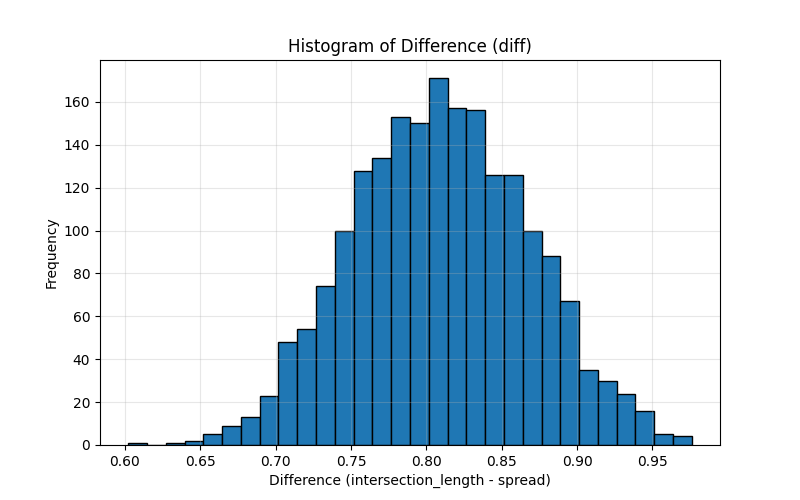

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df['diff'], bins=30, edgecolor='black')
plt.xlabel("Difference (intersection_length - spread)")
plt.ylabel("Frequency")
plt.title("Histogram of Difference (diff)")
plt.grid(True, alpha=0.3)
plt.show()